In [1]:
import spikeinterface.full as si
from pathlib import Path

In [2]:
#PATHS (set here when running standalone; overridden by main_pipeline)
try:
    spikeglx_folder
    base_folder
except NameError:
    spikeglx_folder = Path(r'C:\Users\labuser\Ilaria\Project\small_rec\2142_g0\2142_g0_imec0')
    base_folder     = Path(r'C:\Users\labuser\Ilaria\Project\processed\2142_output')

In [3]:
# SPIKEGLX-SPECIFIC PARAMETERS 
stream_name  = 'imec0.ap'
freq_min     = 300.    # highpass cutoff (Hz)

cref_operator  = 'median'
cref_reference = 'global'

# SORTER (set in main_pipeline; fallback when running standalone)
try:
    sorter = SORTER_KS
except NameError:
    sorter = 'kilosort4'   # 'kilosort2_5' | 'kilosort4'

In [4]:
# LOAD 
raw_rec = si.read_spikeglx(spikeglx_folder, stream_name=stream_name, load_sync_channel=False)
print(raw_rec)

SpikeGLXRecordingExtractor: 384 channels - 30000.386555 Hz - 1 segments - 120,001 samples - 4.00s 
                            int16 dtype - 87.89 MiB


In [5]:
# PREPROCESSING 
rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)
bad_channel_ids, _ = si.detect_bad_channels(rec1)
rec2 = rec1.remove_channels(bad_channel_ids)
rec  = si.common_reference(rec2, operator=cref_operator, reference=cref_reference)
print(rec)

CommonReferenceRecording: 333 channels - 30000.386555 Hz - 1 segments - 120,001 samples - 4.00s 
                          int16 dtype - 76.22 MiB


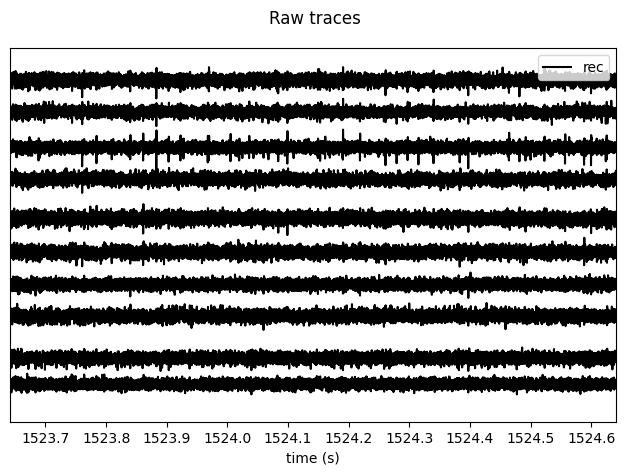

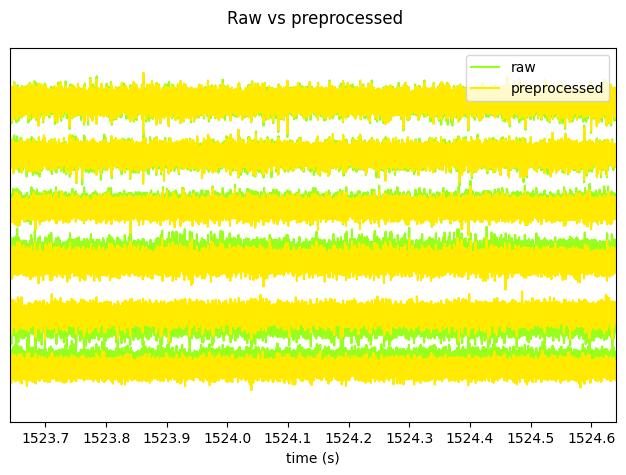

In [6]:
# TRACES VISUALIZATION 
import matplotlib.pyplot as plt
import spikeinterface.widgets as sw

# slice to first 2 s (time_range has a bug in SI 0.103 â€” use frame_slice instead)
_fs = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

# raw traces â€” first 10 channels
sw.plot_traces(raw_2s, channel_ids=raw_rec.channel_ids[:10], mode='line', backend='matplotlib')
plt.suptitle('Raw traces')
plt.tight_layout()
plt.show()

# raw vs preprocessed side by side
sw.plot_traces({'raw': raw_2s, 'preprocessed': rec_2s},
               channel_ids=raw_rec.channel_ids[:6], mode='line', backend='matplotlib')
plt.suptitle('Raw vs preprocessed')
plt.tight_layout()
plt.show()

In [7]:
# SPIKE SORTING
import gc, shutil, json

job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

_preprocess_dir = base_folder / 'preprocess'
_sorter_dir     = base_folder / f'{sorter}_output'

# Release any analyzer left from a previous run — it keeps the preprocess binary
# memory-mapped on Windows, which blocks file deletion on re-run.
try:
    del analyzer
except NameError:
    pass
gc.collect()

def _si_folder_valid(folder):
    """True if folder contains a complete SpikeInterface saved object."""
    if not folder.exists():
        return False
    # saved recording / sorting (si v0.94–0.102+)
    if any((folder / f).exists() for f in ('si_folder.json', 'cached.json', 'cached.pkl', 'cached.pickle')):
        return True
    # sorter output folder (all three marker files must exist, log must show no error)
    if ((folder / 'sorter_output').is_dir()
            and (folder / 'spikeinterface_params.json').exists()
            and (folder / 'spikeinterface_log.json').exists()):
        with open(folder / 'spikeinterface_log.json') as _f:
            _log = json.load(_f)
        return not _log.get('error', False)
    return False

def _safe_rmtree(folder):
    """Delete a folder, raising a clear message if Windows still has a file locked."""
    try:
        shutil.rmtree(folder)
    except PermissionError:
        raise RuntimeError(
            f"Cannot delete '{folder.name}' — a file is still locked by another process.\n"
            "If the spikeinterface_gui is open, close it.\n"
            "Then restart the Jupyter kernel and re-run."
        )

# Preprocessed binary 
if _si_folder_valid(_preprocess_dir):
    rec = si.load(_preprocess_dir)
    print(f"Loaded cached preprocessed recording from '{_preprocess_dir.name}'")
else:
    if _preprocess_dir.exists():           # incomplete folder from a failed previous save
        _safe_rmtree(_preprocess_dir)
    rec = rec.save(folder=_preprocess_dir, format='binary', **job_kwargs)

#  Spike sorting 
if _si_folder_valid(_sorter_dir):
    sorting = si.load(_sorter_dir)
    print(f"Loaded cached sorting from '{_sorter_dir.name}'")
else:
    if _sorter_dir.exists():
        _safe_rmtree(_sorter_dir)
    sorting = si.run_sorter(sorter, rec, folder=_sorter_dir, verbose=True)

print(sorting)

write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=30,000 - chunk_memory=19.05 MiB - total_memory=76.22 MiB - chunk_duration=1.00s (999.99 ms)


write_binary_recording (workers: 4 processes spawn):   0%|          | 0/5 [00:00<?, ?it/s]

Loaded cached sorting from 'kilosort4_output'
KiloSortSortingExtractor: 71 units - 1 segments - 30.0kHz


In [ ]:
#  UNIT REFINEMENT (UnitRefine auto-labelling) 
import sys, subprocess, pandas as pd
import matplotlib.pyplot as plt
import spikeinterface.curation as sc
import spikeinterface.widgets as sw

# auto-install dependencies if missing
for _pkg, _import in [("huggingface_hub", "huggingface_hub"), ("skops", "skops")]:
    try:
        __import__(_import)
    except ModuleNotFoundError:
        subprocess.run([sys.executable, "-m", "pip", "install", _pkg], check=True)

# picks up flag from main_pipeline; defaults to True when running standalone
try:
    _run_ur = RUN_UNITREFINE
except NameError:
    _run_ur = True

analyzer = si.create_sorting_analyzer(sorting=sorting, recording=rec, format="memory")
analyzer.compute([
    "random_spikes",
    "waveforms",
    "templates",
    "noise_levels",
    "spike_amplitudes",
    "principal_components",
    "spike_locations",
    "unit_locations",
    "quality_metrics",
])
# multi-channel template metrics (spread, velocity, exp_decay) required by UnitRefine
analyzer.compute("template_metrics", include_multi_channel_metrics=True)

if _run_ur:
    # Stage 1 — noise vs neural
    noise_df = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="SpikeInterface/UnitRefine_noise_neural_classifier",
        trust_model=True,
    )

    # Stage 2 — SUA vs MUA
    sua_mua_df = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="SpikeInterface/UnitRefine_sua_mua_classifier",
        trust_model=True,
    )

    noise_labels   = noise_df["prediction"]
    sua_mua_labels = sua_mua_df["prediction"]

    # combine: keep noise labels, replace 'neural' with SUA or MUA result
    final_labels = noise_labels.copy()
    neural_mask  = final_labels == "neural"
    final_labels[neural_mask] = sua_mua_labels[neural_mask]

    print(final_labels.value_counts())
    print(f"\nSUA  : {(final_labels == 'sua').sum()}")
    print(f"MUA  : {(final_labels == 'mua').sum()}")
    print(f"Noise: {(final_labels == 'noise').sum()}")

    # expose labels as a 'quality' property — the GUI reads this and shows it in the unit table
    analyzer.sorting.set_property("quality", [final_labels[uid] for uid in analyzer.sorting.unit_ids])

    # ── MATPLOTLIB VISUALIZER (commented out — use the GUI below instead) ──
    # _label_colors = {'sua': 'green', 'mua': 'orange', 'noise': 'red'}
    # unit_colors = {uid: _label_colors[lbl] for uid, lbl in final_labels.items()}
    # w = sw.plot_unit_templates(analyzer, unit_colors=unit_colors)
    # w.figure.suptitle("UnitRefine labelling  (green=SUA · orange=MUA · red=noise)")
    # plt.tight_layout()
    # plt.show()

    # save labels and expose good_unit_ids for downstream use
    final_labels.rename("unitrefine_label").to_csv(base_folder / 'curation_labels.csv', header=True)
    good_unit_ids = final_labels[final_labels == "sua"].index.tolist()
    print(f"\nGood (SUA) units saved to curation_labels.csv")

In [ ]:
# QUALITY METRICS
qm = analyzer.get_extension("quality_metrics").get_data()
print(qm)
qm.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved → {base_folder / 'quality_metrics.csv'}")

In [9]:
# ── INTERACTIVE VIEWER (sigui) ────────────────────────────────
# shows waveforms, ISI, amplitudes, probe map — click any unit to inspect
import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)